# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)

print("users", users.shape)

print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print('Cantidad valores nulos', users.isna().sum())# Cantidad de valores nulos)
print()
print('Proporción valores nulos', users.isna().mean())# Proporción de valores nulos)

Cantidad valores nulos user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción valores nulos user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
  
**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En users las columnas city (11%) y churn_date (88%) tienen datos nulos.
- En usage las columnas date (1%), duration (55%), length (44%) tienen datos nulos.
- Indica qué harías: ¿imputar, eliminar, ignorar?
- Eliminaría los datos nulos de la columna churn_Date de users. Investigaría la calidad de los datos de la columna city, duration, date y lenght. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
columnas_user_num= users[['user_id', 'age']].describe()
print(columnas_user_num)


            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


In [13]:
users['age'].le(0).sum()

55

- La columna `user_id` identifica a cada usuario mediante la asignación de un numero especifico. No se observan sentinels que indiquen error en el registro de usuario.
- La columna `age` contiene sentinels (-999) dicho dato se registra como el minimo. El dato no tiene logica segun la información que se guarda en la columna. Asi mismo, el sentinel afecta la forma en la que se distribuyen los datos.

In [14]:
# explorar columnas numéricas de usage
columnas_usage_num= usage[['id', 'user_id','duration','length']].describe()
print(columnas_usage_num)

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


In [15]:
#evidenciar registros igual o menor a 0
usage['user_id'].le(0).sum()

0

In [16]:
#evidenciar registros nulos
usage['user_id'].isna().sum()

0

In [17]:
#evidenciar registros igual o menor a 0
usage['duration'].le(0).sum()

15

In [58]:
#evidenciar registros nulos
usage['duration'].isna().sum()

22076

In [59]:
#evidenciar registros igual o menor a 0
usage['length'].le(0).sum()

133

In [60]:
#evidenciar registros nulos
usage['length'].isna().sum()

17896

- Las columnas `id` y `user_id` identifica a cada usuario mediante la asignación de un numero especifico. No se observan sentinels que indiquen error en el registro de usuario.
- Las columnas 'duration' y 'length' tienen valores nulos. Hay valores en 0.

In [21]:
# explorar columnas categóricas de users
columnas_user = users[['city','plan']].describe()
print(columnas_user)




          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


In [22]:
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [23]:
users['city'].isna().sum()

469

In [24]:
users['plan'].value_counts()

Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` tiene un dato erroneo identificado como '?' con 96 registros. Hay ciudades registradas con abreviatura.
- La columna `plan` no tiene valores nulos. El plan dominante es el 'Basico'.

In [25]:
# explorar columna categórica de usage
usage['type'].describe()# completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [26]:
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` no tiene valores nulos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  Se encontraron valores invalidos en las columnas: city, age, duration, length.
- ¿Qué acción tomarías?
  Reemplazar '-999' en la columna 'age' para normalizar la distribución de los datos. Reemplazar '?' por nulo en la columna age. Determinar la razon de los valores nulos en duration y length.
  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [27]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date']= pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [28]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')# completa el código

In [29]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observan 40 datos con año 2026.

In [30]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

In [31]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [32]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


En `date`, hubo valores que no se pudieron convertir a formato fecha.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Se observaron registros con el año 2026, lo cual era ilogico toda vez que el ultimo año de registro fue 2024.
- ¿Qué harías con ellas?
  Reemplazar con nulo los registros con año 2026.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [33]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
print(age_mediana)
users['age']= users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

47.0


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [34]:
# Reemplazar ? por NA en city
users['city']= users['city'].replace('?', 'NA')

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64

In [35]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > '2024-12-31', 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts().sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [36]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_vacia']= usage['duration'].isna().astype(int)
usage.head()

,id,user_id,type,date,duration,length,duration_vacia
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN,0
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0,1
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0,1
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN,0
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN,0


In [37]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_vacia']= usage['length'].isna().astype(int)
usage.head()

,id,user_id,type,date,duration,length,duration_vacia,length_vacia
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN,0,1
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0,1,0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0,1,0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN,0,1
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN,0,1


Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`
La columna 'type' con los valores text y call determinan el valor o el nulo de duration y length ya que cuando type es "call", length es NaN (porque no se puede medir la longitud de caracteres en una llamada).
Cuando type es "text", duration es NaN (porque no se puede medir la duración de un mensaje de texto).
Esta es una situación de MNAR (Missing Not At Random) ya que los valores faltantes tienen una razón específica relacionada con la naturaleza del dato.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [38]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum','is_call': 'sum','duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [39]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas', 
    'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [40]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile=pd.merge(usage_agg, users, on=['user_id'], how='inner')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [41]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,23.317054,48.124531
std,1154.898108,2.358416,2.144238,18.168095,17.692032
min,10000.000000,0.000000,0.000000,0.000000,18.000000
25%,10999.500000,4.000000,3.000000,11.120000,33.000000
50%,12000.000000,5.000000,4.000000,19.780000,47.000000
75%,12999.500000,7.000000,6.000000,31.415000,63.000000
max,13999.000000,17.000000,15.000000,155.690000,79.000000


In [42]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)


Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

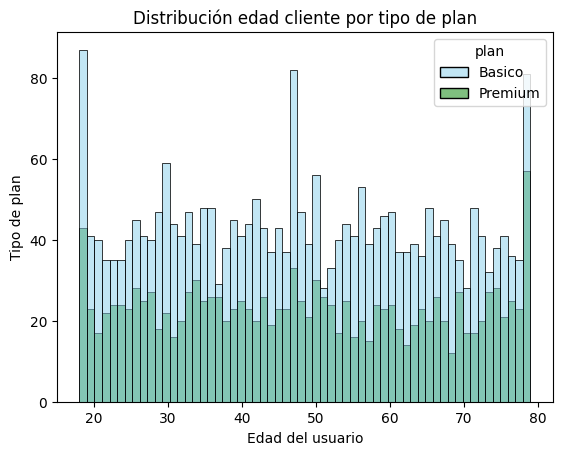

In [43]:
# Histograma para visualizar la edad (age)
# bins= 60 considerando que la raiz cuadrada de 4000(numero de registros) es 63
sns.histplot(data=user_profile, x='age', bins=60, hue='plan', palette=['skyblue','green'])
plt.xlabel('Edad del usuario')
plt.ylabel('Tipo de plan')
plt.title('Distribución edad cliente por tipo de plan')
plt.show()

💡Insights: 
Los clientes de mayor edad (66-67 años) tienen preferencia por el plan Premium.
Hay una mayor distribución en el plan Basico con clientes entre los 47-48 años.

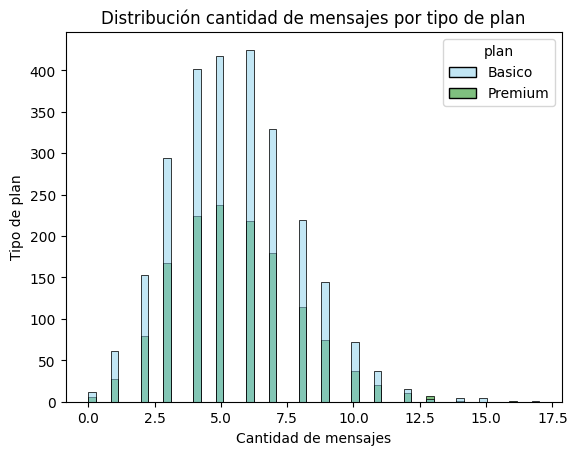

In [44]:
# Histograma para visualizar la cant_mensajes
# bins= 60 considerando que la raiz cuadrada de 4000(numero de registros) es 63
sns.histplot(data=user_profile, x='cant_mensajes', bins=60, hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Tipo de plan')
plt.title('Distribución cantidad de mensajes por tipo de plan')
plt.show()


💡Insights: 
- Los usuarios Premium tienden a mandar mayor numero de mensajes.
- La distribución entre la cantidad de mensajes y el tipo de plan es similar entre los usuarios.
- Existen outliers que provocan una distribución hacia la derecha por parte de los datos. 

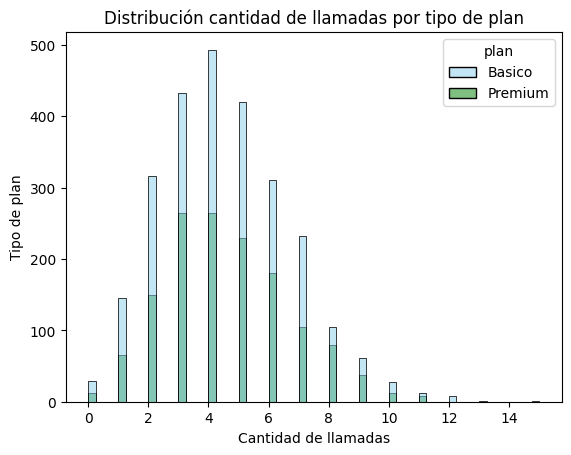

In [45]:
# Histograma para visualizar la cant_llamadas
# bins= 60 considerando que la raiz cuadrada de 4000(numero de registros) es 63
sns.histplot(data=user_profile, x='cant_llamadas', bins=60, hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Tipo de plan')
plt.title('Distribución cantidad de llamadas por tipo de plan')
plt.show()


💡Insights: 
- La distribución entre la cantidad de llamadas y el tipo de plan es similar entre los usuarios.
- Existen outliers que provocan una distribución hacia la derecha por parte de los datos. 

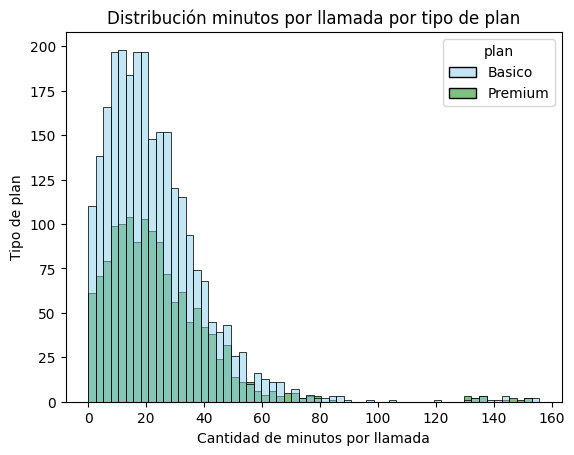

In [46]:
# Histograma para visualizar la cant_minutos_llamada
# bins= 60 considerando que la raiz cuadrada de 4000(numero de registros) es 63
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=60, hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Tipo de plan')
plt.title('Distribución minutos por llamada por tipo de plan')
plt.show()

💡Insights: 
- Los usuarios con plan Basico muestran tener una mayor cantidad de minutos por llamada.
- Existen outliers que provocan una distribución hacia la derecha por parte de los datos. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

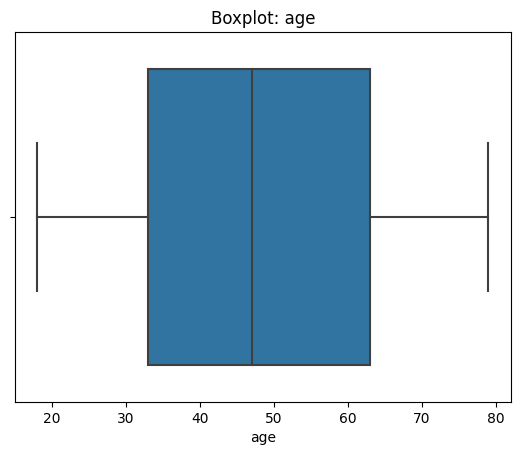

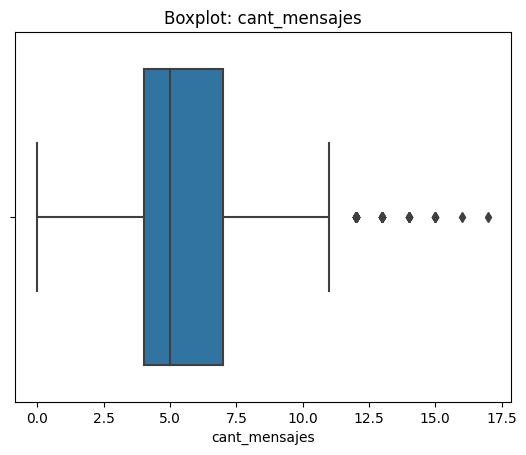

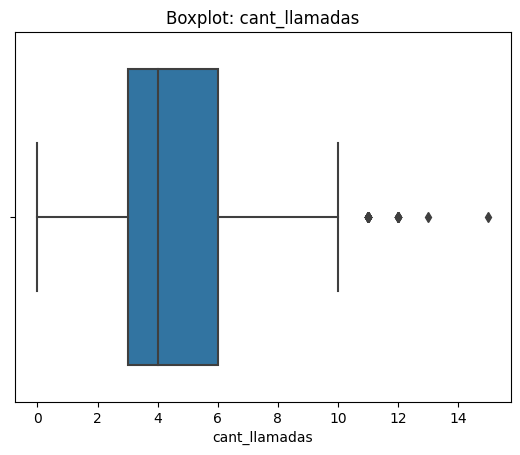

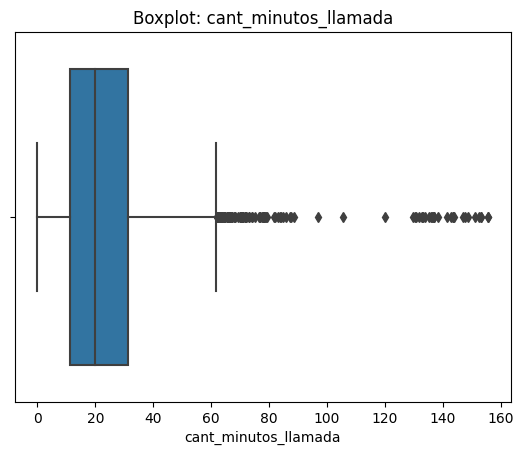

In [47]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers
- cant_mensajes: Si presenta outliers
- cant_llamadas: Si presenta outliers
- cant_minutos_llamada: Si presenta outliers

In [48]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1= user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers_superiores = (user_profile[col]> limite_superior).sum()
    print(f"\n{col}:")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Valor máximo actual: {user_profile[col].max():.2f}")
    print(f"Outliers superiores: {outliers_superiores}")


age:
Q1: 33.00, Q3: 63.00
Límite inferior: -12.00
Límite superior: 108.00
Valor máximo actual: 79.00
Outliers superiores: 0

cant_mensajes:
Q1: 4.00, Q3: 7.00
Límite inferior: -0.50
Límite superior: 11.50
Valor máximo actual: 17.00
Outliers superiores: 46

cant_llamadas:
Q1: 3.00, Q3: 6.00
Límite inferior: -1.50
Límite superior: 10.50
Valor máximo actual: 15.00
Outliers superiores: 30

cant_minutos_llamada:
Q1: 11.12, Q3: 31.41
Límite inferior: -19.32
Límite superior: 61.86
Valor máximo actual: 155.69
Outliers superiores: 109


In [49]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener debido a que se esta registrando el uso real del usuario. Existen clientes que por diferentes circuntancias usan con mayor frecuencia los servicios moviles. Como recomendación, se puede considerar winsorizar debido a que los datos extremos son posibles pero raros o poco frecuentes.
- cant_llamadas: mantener debido a que se esta registrando el uso real del usuario. Existen clientes que por diferentes circuntancias usan con mayor frecuencia los servicios moviles. Como recomendación, se puede considerar winsorizar debido a que los datos extremos son posibles pero raros o poco frecuentes.
- cant_minutos_llamada: mantener debido a que se esta registrando el uso real del usuario. Existen clientes que por diferentes circuntancias usan con mayor frecuencia los servicios moviles. Como recomendación, se puede hacer un analisis a profundidad para determinar que tipo de usuarios son lo que registran llamadas por arriba del limite superior calculado en el presente estudio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [50]:
# Crear columna grupo_uso

def classify_customer(row):
    llamadas= row['cant_llamadas']
    mensajes= row['cant_mensajes']
#segmentación llamadas, mensajes <5
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
        #segmentación <10
    elif llamadas <10 and mensajes <10:
        return 'Uso medio'
        #segmentación resto
    else:
        return 'Alto uso'
     
#aplicar función y ver cambios
user_profile['grupo_uso']= user_profile.apply(classify_customer, axis=1)



In [51]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [52]:
# Crear columna grupo_edad
def classify_age(row):
    edad= row['age']
    #segmentación <30
    if edad < 30:
        return 'Joven'
        #segmentación <60
    elif edad <60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
#aplicar función
user_profile['grupo_edad']= user_profile.apply(classify_age, axis=1)

In [53]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

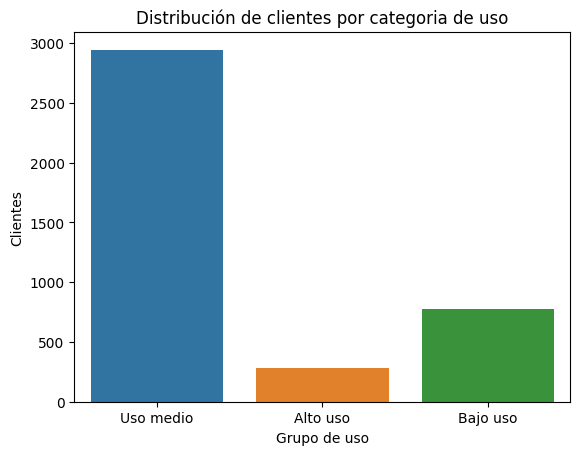

In [54]:
# Visualización de los segmentos por uso
sns.countplot(data= user_profile, x='grupo_uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Clientes')
plt.title('Distribución de clientes por categoria de uso')
plt.show()

In [55]:
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      278
Name: grupo_uso, dtype: int64

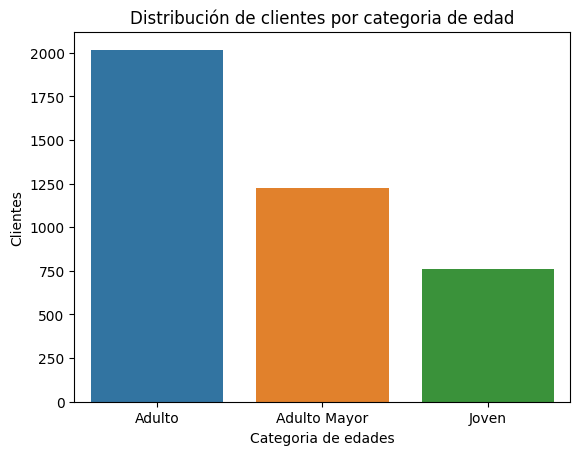

In [56]:
# Visualización de los segmentos por edad
sns.countplot(data= user_profile, x='grupo_edad')
plt.xlabel('Categoria de edades')
plt.ylabel('Clientes')
plt.title('Distribución de clientes por categoria de edad')
plt.show()

In [57]:
user_profile['grupo_edad'].value_counts()

Adulto          2017
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Presencia de outliers '?' en la columna city del dataset users. En total eran 96 registros.
- En el dataset users las columnas city (11%) y churn_date (88%) tenian datos nulos.
- En el dataset usage las columnas date (1%), duration (55%), length (44%) tenian datos nulos. Sin embargo en duration y lenght se destaca que dichos datos nulos tenian un patrón y razón para marcarse intencionalmente como nulo.
- La columna age contenia 55 registros denominados como sentinels (-999), los cuales distorcionaban la distribución normal de los datos de dicha columna.

🔍 **Segmentos por Edad**
- El segmento denominado como adulto es el grupo de clientes que mayor participación tiene en ConnectaTel con un total de 2017 registros. Lo anterior se corrobora con la media de la edad la cual corresponde a 48 años. Esto indica que la mayor parte del negocio proviene de clientes maduros con mayor compromiso comercial y compras estables. Le continua el segmento Adulto Mayor con un total de 1222 registros los cuales sugieren tener los mismos beneficios comerciales estables pero con la distinción de que el tiempo en cuestión de la edad es un factor determinante respecto al termino de la relación comercial.
- El segmento denominado como joven es el grupo de clientes que menor parcipación tiene en ConnectaTel con un total de 760 registros. Dichos clientes sugieren ser el futuro del sustento comercial de la empresa. 

📊 **Segmentos por Nivel de Uso**
- Los clientes se encuentran segmentados en mayor proporción en la categoria Uso Medio con un total de 2943 registros. Esto sugiere que los usuarios tienen una relación cercana e importante con la linea en materia de comunicación. Un uso considerable sugiere que la linea puede ser usada como herramienta de trabajo.
- Le continua la categoria Bajo Uso con 778 registros mientras que el segmento Alto Uso solo registro 278 datos. Respecto a este ultimo segmento cabe señalar que hubo presencia de usuarios que mostraron un alto consumo en lo que respecta a en la cantidad de minutos por llamada.


➡️ Esto sugiere que la mayoria de los clientes de ConnectaTe son personas adultas con una media de 48 años, lo que determina una relación comercial madura. Asi mismo, dicha relación se vincula a que los usuarios usan de manera constante la linea para realizar llamadas y mensajes por lo que dicha situación puede sugerir que adquirir el servicio de comunicación se usa para actividades profesionales, relaciones laborales o como herramienta de trabajo.

En otro sentido, se presenciaron 109 registros en lo que respecta a la cantidad de minutos por llamada muy por arriba del limite superior calculado (outliers). Esto sugiere usuarios con patrones de uso extremo por lo que puede ser un segmento o area de estudio importante para el negocio. Si bien no es un segmento de usuarios con alto numero de registros, analizar el caso puede generar estrategias de retención especifica. Son datos extremos, sin embargo son numeros reales sobre el comportamiento genuino de ciertos usuarios.


💡 **Recomendaciones**
- Mejorar los planes o servicios ofertados a los usuarios jovenes para incentivar un uso mayor de la linea, destacando que dicha categoria suele usar las telecomunicaciones como entretemiento.
- Realizar un analisis para usuarios con uso extremo para determinar que tan valiosos pueden ser para ConnectaTel y con base a ello determinar que tipo de plan o servicio se puede crear para atacar dicho segmento.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`